<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Processamento_de_Imagem_Mecha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importar Bibliotecas
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
from google.colab import files, drive
from skimage.metrics import structural_similarity as compare_ssim
from PIL import Image
import matplotlib.pyplot as plt
import os

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Função para carregar imagens
def carregar_imagens():
    uploaded = files.upload()  # Permite ao usuário fazer upload de imagens
    imagens = []
    nomes = []
    for nome_arquivo in uploaded.keys():
        img = cv2.imread(nome_arquivo)
        if img is not None:
            imagens.append(img)
            nomes.append(nome_arquivo)
    return imagens, nomes

In [4]:
# Carregar imagens
imagens, nomes = carregar_imagens()

Saving 02.JPG to 02.JPG
Saving 03.JPG to 03.JPG
Saving 04.JPG to 04.JPG
Saving 05.JPG to 05.JPG
Saving 06.JPG to 06.JPG
Saving 07.JPG to 07.JPG
Saving 08.JPG to 08.JPG
Saving 09.JPG to 09.JPG
Saving 10.JPG to 10.JPG
Saving 11.JPG to 11.JPG
Saving 12.JPG to 12.JPG
Saving 13.JPG to 13.JPG
Saving 14.JPG to 14.JPG
Saving 15.JPG to 15.JPG
Saving 16.JPG to 16.JPG
Saving 17.JPG to 17.JPG
Saving 18.JPG to 18.JPG
Saving 19.JPG to 19.JPG
Saving 20.JPG to 20.JPG


In [5]:
import matplotlib.pyplot as plt
import cv2

# Função para exibir imagens em uma grade
def exibir_imagens_em_grade(imagens, titulos=None, max_colunas=4):
    num_imagens = len(imagens)
    num_linhas = -(-num_imagens // max_colunas)  # Calcula o número de linhas usando divisão inteira arredondada para cima

    plt.figure(figsize=(max_colunas * 3, num_linhas * 3))  # Ajusta o tamanho da figura com base no número de colunas e linhas

    for i, img in enumerate(imagens):
        plt.subplot(num_linhas, max_colunas, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Converte BGR para RGB
        if titulos:
            plt.title(titulos[i], fontsize=10)  # Ajusta o tamanho da fonte do título
        plt.axis('off')

    # Ajusta o espaçamento entre as imagens
    plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Reduz o espaçamento horizontal e vertical
    plt.show()


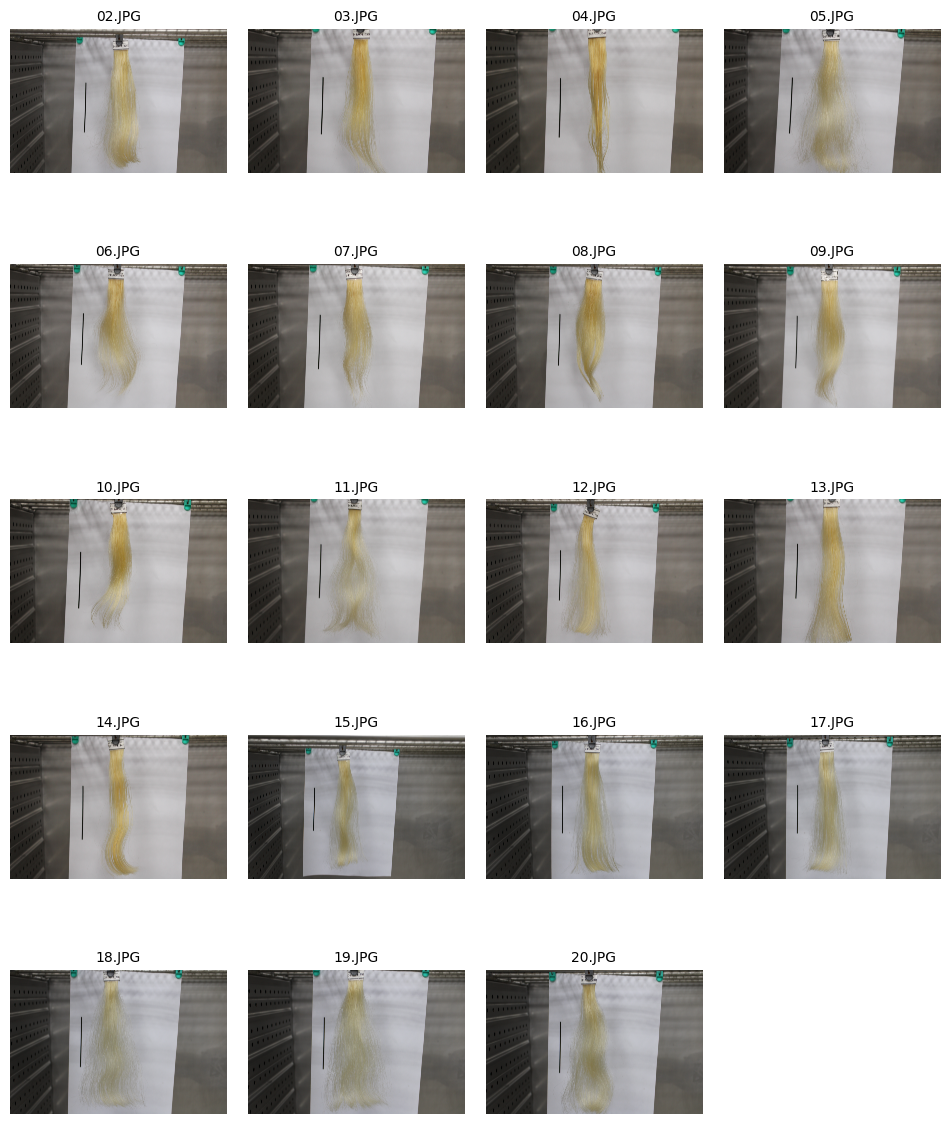

In [6]:
exibir_imagens_em_grade(imagens, nomes)

In [115]:
# Função para detectar a mecha de cabelo e calcular a área
def detectar_mecha_e_calcular_area(imagem):
    # Converter para o espaço de cores HSV
    hsv = cv2.cvtColor(imagem, cv2.COLOR_BGR2HSV)

    # Intervalos de cores para diferentes tipos de cabelo
    intervalos = {
        "loiro": (np.array([20, 0, 125]), np.array([40, 255, 230])),  # Cabelo loiro; para mais acinzentado, baixar S.
        "castanho": (np.array([10, 50, 50]), np.array([20, 200, 200])),  # Cabelo castanho
        "ruivo": (np.array([0, 50, 50]), np.array([10, 255, 255])),  # Cabelo ruivo
    }

    # Criar máscaras combinadas para os intervalos desejados
    mask = sum(cv2.inRange(hsv, *intervalo) for intervalo in intervalos.values())

    # Operações morfológicas para limpar a máscara
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))  # Kernel para operações morfológicas
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)  # Fechamento para preencher pequenos buracos
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)  # Abertura para remover pequenos ruídos

    # Encontrar contornos na máscara
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    # Filtrar contornos pequenos
    contours = [contorno for contorno in contours if cv2.contourArea(contorno) >= 100]

    if not contours:
        print("Nenhum contorno encontrado!")
        return imagem, None, 0, 0

    # Selecionar o maior contorno
    maior_contorno = max(contours, key=cv2.contourArea)
    area_mecha = cv2.contourArea(maior_contorno)

    # Desenhar o contorno na imagem
    imagem_com_contorno = imagem.copy()
    cv2.drawContours(imagem_com_contorno, [maior_contorno], -1, (0, 255, 0), 2)  # Verde para o contorno

    # Detectar a linha preta para calcular a área relativa
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 50]))
    contours_black, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours_black:
        print("Linha preta não encontrada!")
        return imagem_com_contorno, maior_contorno, area_mecha, 0

    # Selecionar o maior contorno da linha preta
    linha_preta = max(contours_black, key=cv2.contourArea)
    area_linha_preta = cv2.contourArea(linha_preta)

    # Calcular a área relativa
    area_relativa = area_mecha / area_linha_preta if area_linha_preta > 0 else 0

    return imagem_com_contorno, maior_contorno, area_mecha, area_relativa


In [116]:
# Processar cada imagem com pré-processamento e exibir etapas intermediárias
def processar_e_exibir_imagens(imagens, nomes, max_colunas=4):
    imagens_com_contorno = []
    titulos = []
    resultados = []  # Lista para armazenar os dados para o Excel

    for i, img in enumerate(imagens):

        # Detectar a mecha e calcular a área na imagem original
        imagem_original_com_contorno, maior_contorno_original, area_original, area_relativa_original = detectar_mecha_e_calcular_area(img)

        # Adicionar as imagens com contornos à lista
        imagens_com_contorno.append(imagem_original_com_contorno)

        # Criar títulos para exibição, código para adicionar: \nÁrea Original: {area_original:.2f}
        titulos.append(f"{nomes[i]}\nÁrea Relativa: {area_relativa_original:.2f}")

        # Adicionar os resultados ao DataFrame
        resultados.append({
            "Nome": nomes[i],
            "Área Original": round(area_original, 2),
            "Área Relativa Original": round(area_relativa_original, 2),
        })

    # Criar um DataFrame do pandas com os resultados
    df = pd.DataFrame(resultados)

    # Salvar o DataFrame em um arquivo Excel
    df.to_excel("Resultado Frizz.xlsx", index=False)

    print("Resultados salvos no arquivo: 'Resultado Frizz.xlsx'")

    # Exibir todas as imagens com contornos em uma grade
    exibir_imagens_em_grade(imagens_com_contorno, titulos, max_colunas)


Resultados salvos no arquivo: 'Resultado Frizz.xlsx'


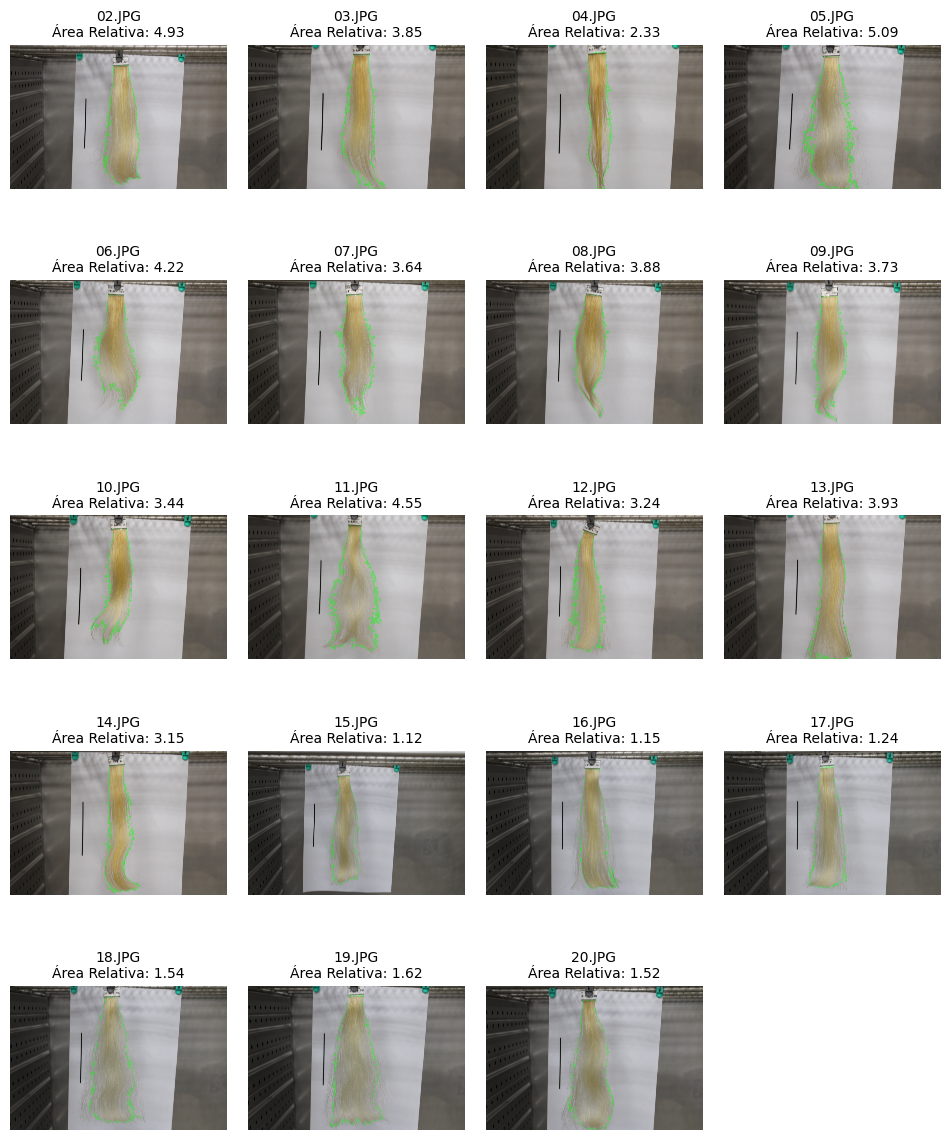

In [117]:
# Chamar a função para processar e exibir as imagens
processar_e_exibir_imagens(imagens, nomes)